In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix,classification_report, matthews_corrcoef
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, multilabel_confusion_matrix



import warnings
warnings.filterwarnings('ignore')

## Data Gathering 

In [2]:
original_df = pd.read_csv('noshowappointments-kagglev2-may-2016.csv')
df=original_df.copy()
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [4]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [5]:
df.shape

(110527, 14)

In [6]:
df.rename(columns={'AppointmentID':'AppointmentId'},inplace=True)
df.rename(columns={'No-show':'NoShow'},inplace=True)
df.rename(columns={'SMS_received':'SMSReceived'},inplace=True)

### Target Feature

In [7]:
df['NoShow'].value_counts(normalize=True)*100

NoShow
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64

<Axes: xlabel='NoShow'>

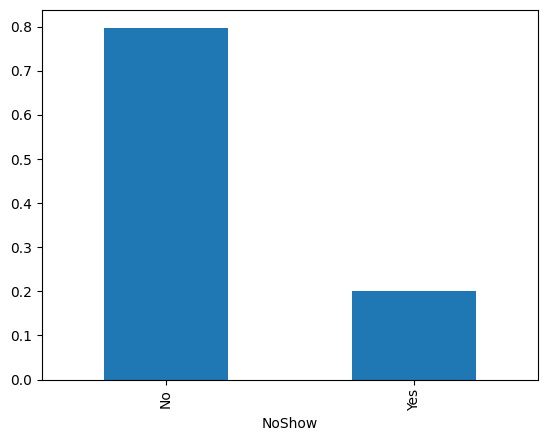

In [8]:
df['NoShow'].value_counts(normalize=True).plot.bar()

## Data Cleaning

In [9]:
df.isna().sum()

PatientId         0
AppointmentId     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMSReceived       0
NoShow            0
dtype: int64

##### There is not any null value in data set

#### 1. Gender

In [10]:
df['Gender'].value_counts(normalize=True)

Gender
F    0.649977
M    0.350023
Name: proportion, dtype: float64

##### There is 65% Female and 35% male  

In [11]:
df['Gender'].replace({'F':0,'M':1},inplace=True)

In [12]:
df.head()

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow
0,2.987250e+13,5642903,0,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,1,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,0,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,0,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,0,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


#### Age

<Axes: >

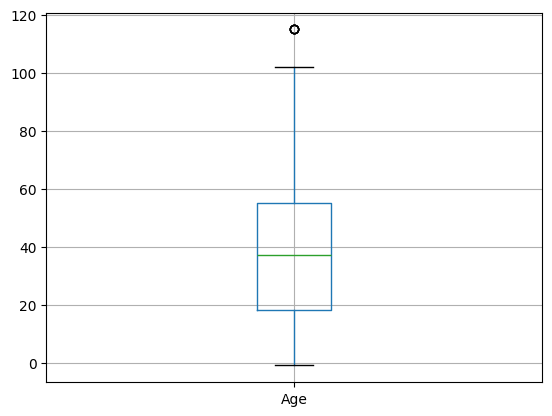

In [13]:
df.boxplot('Age')

In [14]:
q1 = df['Age'].quantile(0.25)
q2 = df['Age'].quantile(0.5)
q3 = df['Age'].quantile(0.75)

print('Q1 == ', q1)
print('Q2 == ', q2)
print('Q3 == ', q3)

iqr = q3 - q1
print('IQR == ', iqr)

upper_tail = q3 + 1.5* iqr
lower_tail = q1 - 1.5* iqr

print('Upper Tail == ', upper_tail)
print('Lower Tail == ', lower_tail)

Q1 ==  18.0
Q2 ==  37.0
Q3 ==  55.0
IQR ==  37.0
Upper Tail ==  110.5
Lower Tail ==  -37.5


In [15]:
df['Age'] = np.where(df['Age'] > upper_tail, upper_tail, df['Age'])

<Axes: >

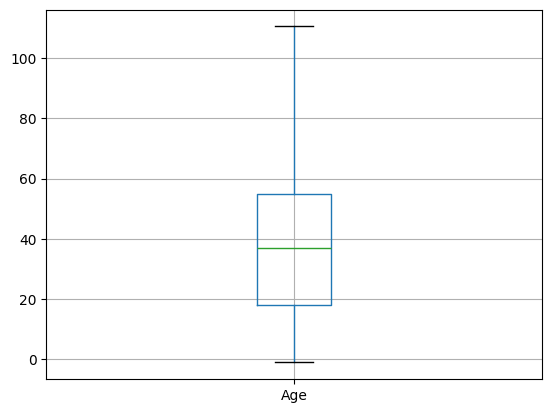

In [16]:
df.boxplot('Age')

In [17]:
df['Age'].skew()

0.12141160598750629

In [18]:
df['Neighbourhood'].unique()

array(['JARDIM DA PENHA', 'MATA DA PRAIA', 'PONTAL DE CAMBURI',
       'REPÚBLICA', 'GOIABEIRAS', 'ANDORINHAS', 'CONQUISTA',
       'NOVA PALESTINA', 'DA PENHA', 'TABUAZEIRO', 'BENTO FERREIRA',
       'SÃO PEDRO', 'SANTA MARTHA', 'SÃO CRISTÓVÃO', 'MARUÍPE',
       'GRANDE VITÓRIA', 'SÃO BENEDITO', 'ILHA DAS CAIEIRAS',
       'SANTO ANDRÉ', 'SOLON BORGES', 'BONFIM', 'JARDIM CAMBURI',
       'MARIA ORTIZ', 'JABOUR', 'ANTÔNIO HONÓRIO', 'RESISTÊNCIA',
       'ILHA DE SANTA MARIA', 'JUCUTUQUARA', 'MONTE BELO',
       'MÁRIO CYPRESTE', 'SANTO ANTÔNIO', 'BELA VISTA', 'PRAIA DO SUÁ',
       'SANTA HELENA', 'ITARARÉ', 'INHANGUETÁ', 'UNIVERSITÁRIO',
       'SÃO JOSÉ', 'REDENÇÃO', 'SANTA CLARA', 'CENTRO', 'PARQUE MOSCOSO',
       'DO MOSCOSO', 'SANTOS DUMONT', 'CARATOÍRA', 'ARIOVALDO FAVALESSA',
       'ILHA DO FRADE', 'GURIGICA', 'JOANA D´ARC', 'CONSOLAÇÃO',
       'PRAIA DO CANTO', 'BOA VISTA', 'MORADA DE CAMBURI', 'SANTA LUÍZA',
       'SANTA LÚCIA', 'BARRO VERMELHO', 'ESTRELINHA', 'FORTE SÃO 

In [19]:
df['Neighbourhood'].nunique()

81

## EDA

In [20]:
df['Gender'].value_counts()

Gender
0    71840
1    38687
Name: count, dtype: int64

In [21]:
df['NoShow'].value_counts()*100

NoShow
No     8820800
Yes    2231900
Name: count, dtype: int64

In [22]:
pd.crosstab(df['Gender'],df['NoShow'])

NoShow,No,Yes
Gender,,
0,57246,14594
1,30962,7725


<Axes: xlabel='Gender', ylabel='count'>

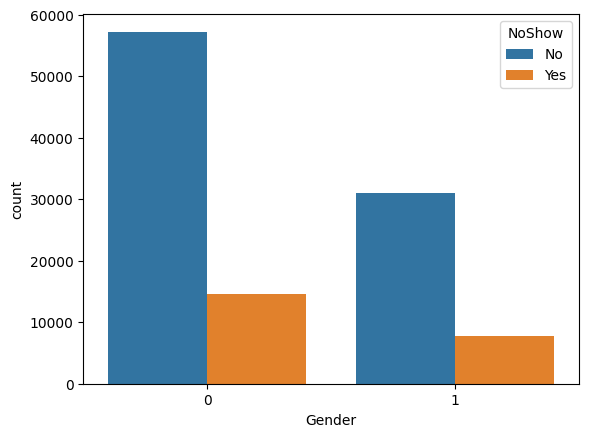

In [23]:
sns.countplot(x = df['Gender'], hue= df['NoShow'])

### Age vs Noshow

<Axes: xlabel='Age', ylabel='count'>

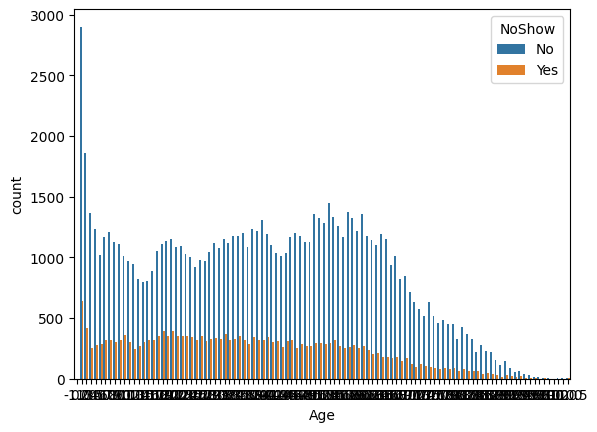

In [24]:
sns.countplot(x=df['Age'], hue= df['NoShow'])

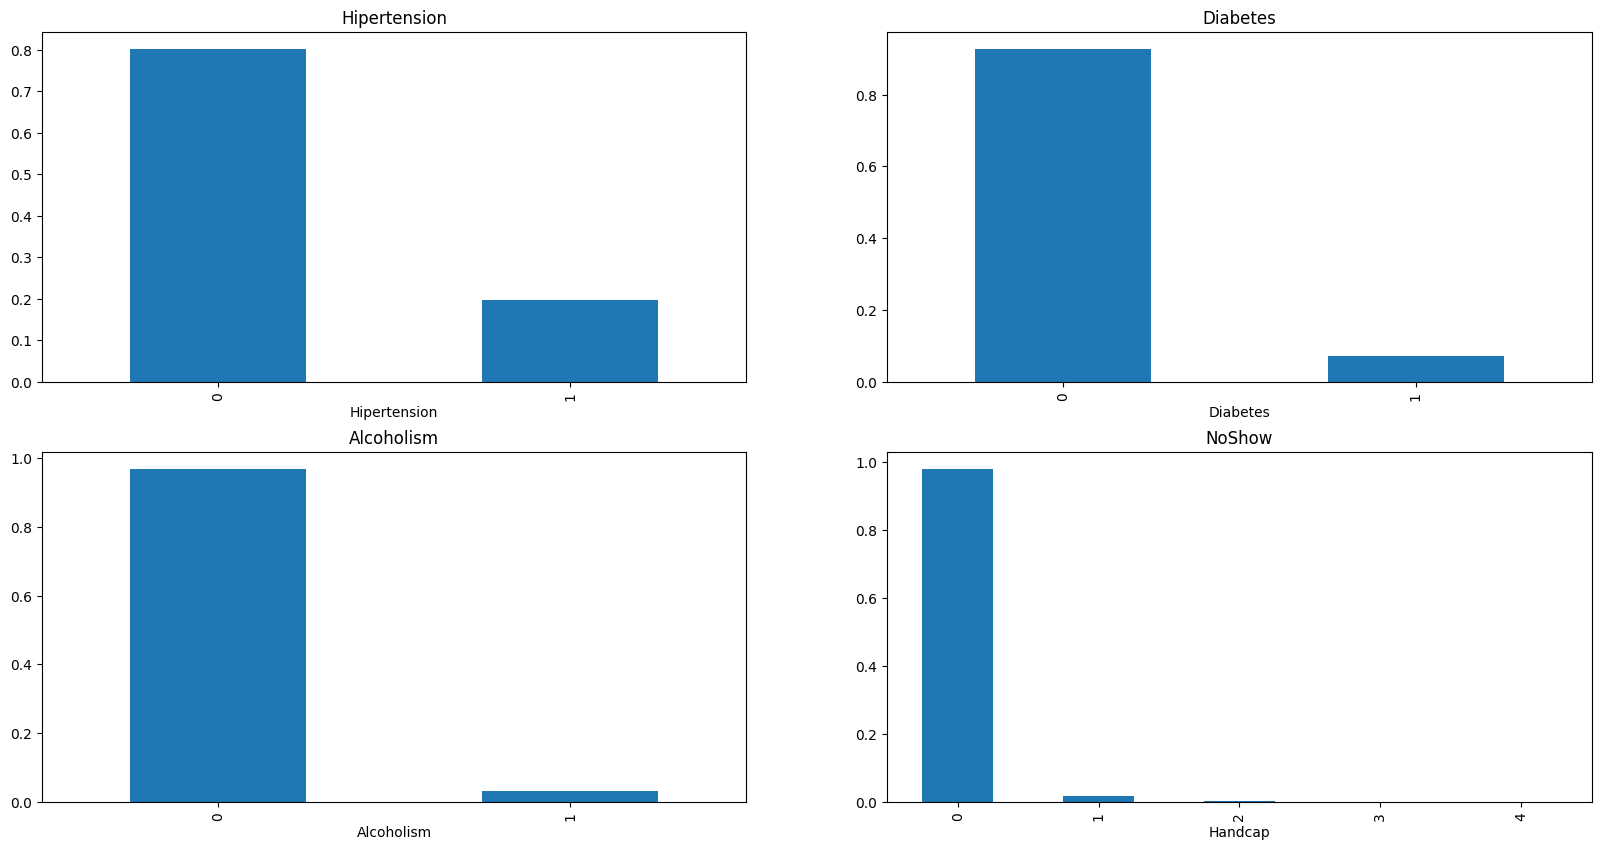

In [25]:
plt.figure(1) 
plt.subplot(221)
df['Hipertension'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Hipertension') 
plt.subplot(222) 
df['Diabetes'].value_counts(normalize=True).plot.bar(title= 'Diabetes')
plt.subplot(223) 
df['Alcoholism'].value_counts(normalize=True).plot.bar(title= 'Alcoholism')
plt.subplot(224) 
df['Handcap'].value_counts(normalize=True).plot.bar(title= 'NoShow')
plt.show()

##### 3.1 Hypetension with NoShow

<Axes: xlabel='Hipertension', ylabel='count'>

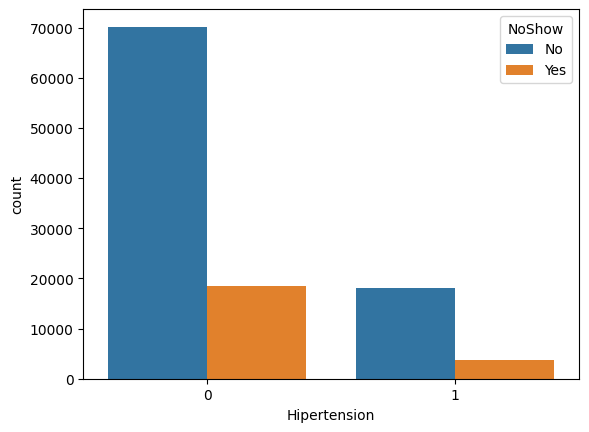

In [26]:
sns.countplot(x = df['Hipertension'], hue= df['NoShow'])

#### 3.2Diabetes with NoShow

<Axes: xlabel='Diabetes', ylabel='count'>

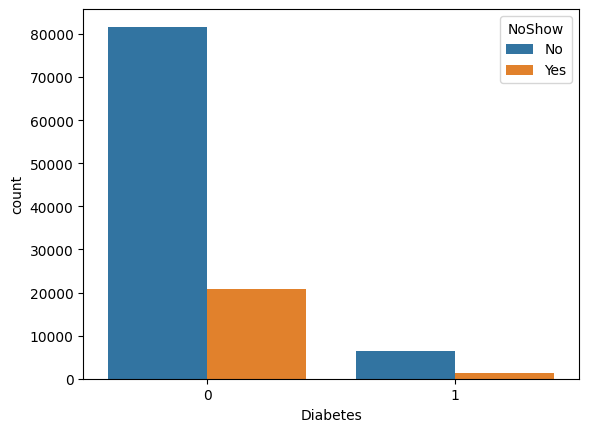

In [27]:
sns.countplot(x = df['Diabetes'], hue= df['NoShow'])

##### 3.3 Alcoholism with NoShow

<Axes: xlabel='Alcoholism', ylabel='count'>

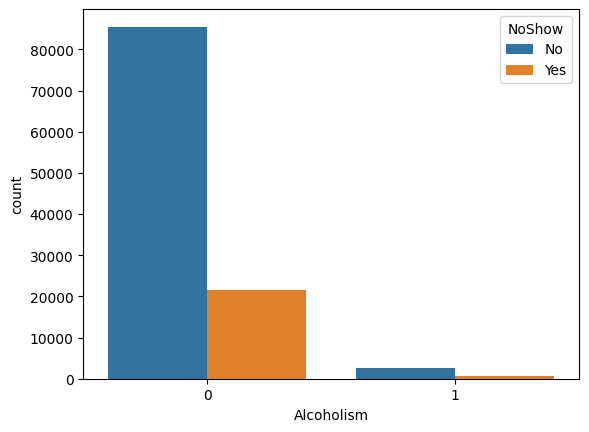

In [28]:
sns.countplot(x = df['Alcoholism'], hue= df['NoShow'])

##### 3.4 Handicape with NoShow

<Axes: xlabel='Handcap', ylabel='count'>

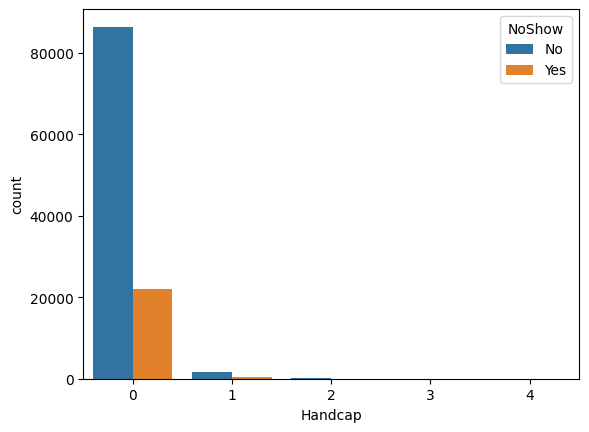

In [29]:
sns.countplot(x = df['Handcap'], hue= df['NoShow'])

In [30]:
pd.crosstab(df['Handcap'],df['NoShow'])

NoShow,No,Yes
Handcap,,
0,86374,21912
1,1676,366
2,146,37
3,10,3
4,2,1


##### 3.5 Hypetension with Gender

<Axes: xlabel='Hipertension', ylabel='count'>

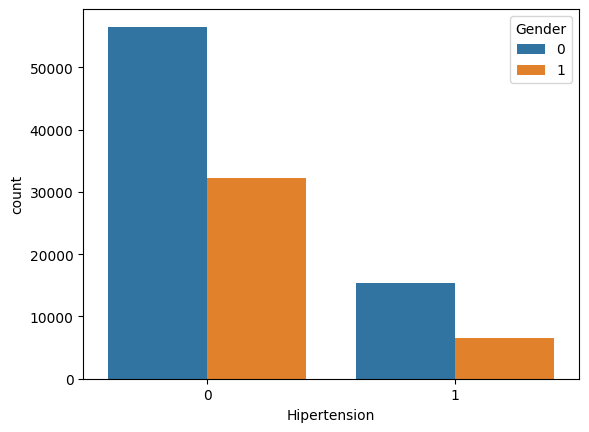

In [31]:
sns.countplot(x = df['Hipertension'], hue= df['Gender'])

##### 3.6 Diabetes with Gender

<Axes: xlabel='Diabetes', ylabel='count'>

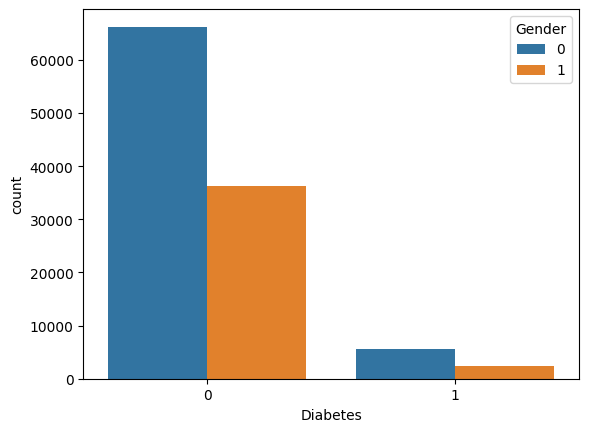

In [32]:
sns.countplot(x = df['Diabetes'], hue= df['Gender'])

In [33]:
pd.crosstab(df['Diabetes'],df['Gender'])

Gender,0,1
Diabetes,,
0,66234,36350
1,5606,2337


##### 3.7 Alcoholism with Gender

<Axes: xlabel='Alcoholism', ylabel='count'>

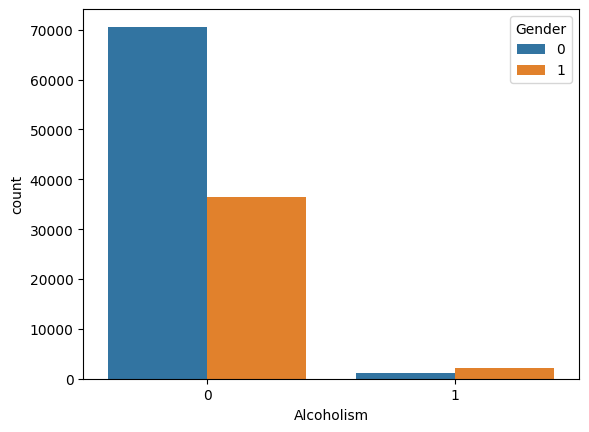

In [34]:
sns.countplot(x = df['Alcoholism'], hue= df['Gender'])

In [35]:
pd.crosstab(df['Alcoholism'],df['Gender'])

Gender,0,1
Alcoholism,,
0,70617,36550
1,1223,2137


##### 3.8 Handicap with Gender

<Axes: xlabel='Handcap', ylabel='count'>

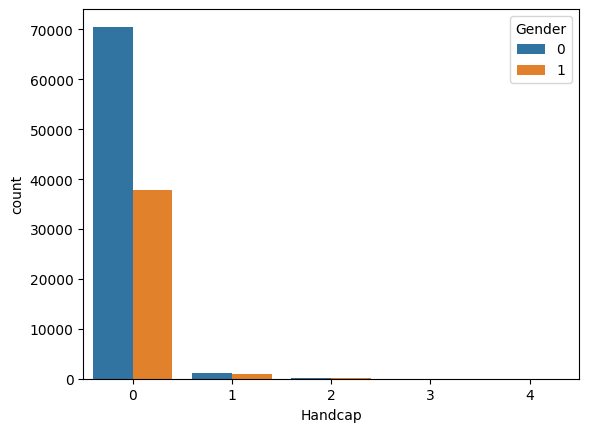

In [36]:
sns.countplot(x = df['Handcap'], hue= df['Gender'])

In [37]:
pd.crosstab(df['Handcap'],df['Gender'])

Gender,0,1
Handcap,,
0,70550,37736
1,1181,861
2,105,78
3,3,10
4,1,2


### SMS

<Axes: xlabel='SMSReceived', ylabel='count'>

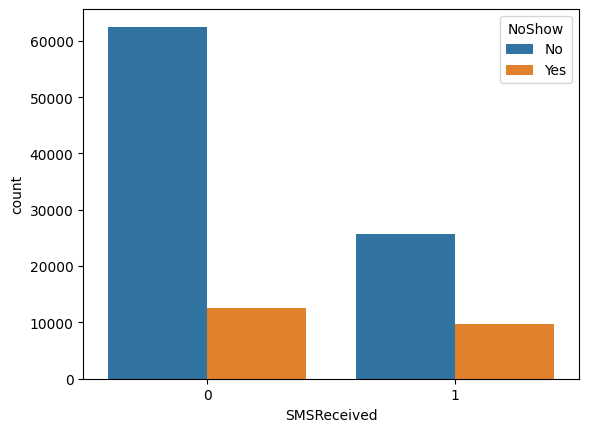

In [38]:
sns.countplot(x = df['SMSReceived'], hue= df['NoShow'])

<function matplotlib.pyplot.show(close=None, block=None)>

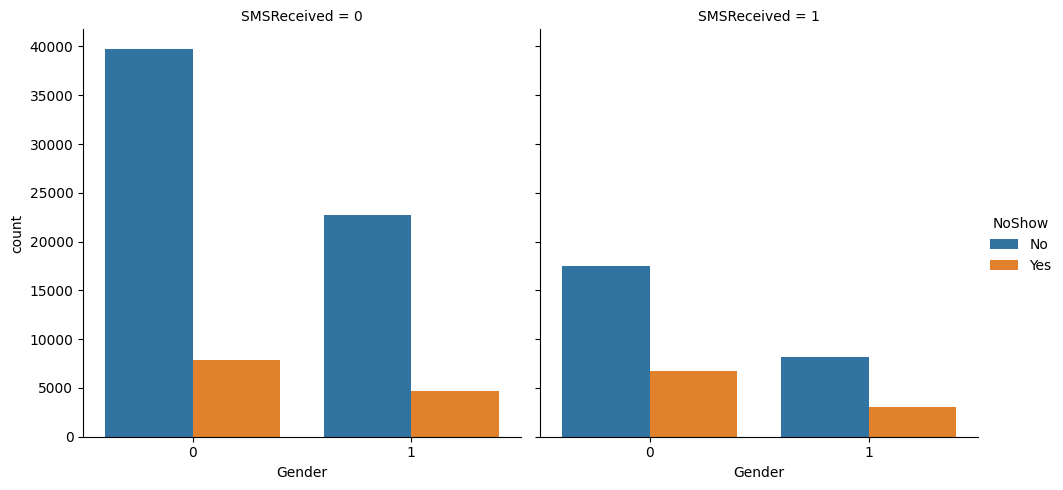

In [39]:
sns.catplot(x='Gender', hue='NoShow', col='SMSReceived', kind='count', data=df)
plt.savefig('sms2.png')
plt.show

<Axes: xlabel='SMSReceived', ylabel='count'>

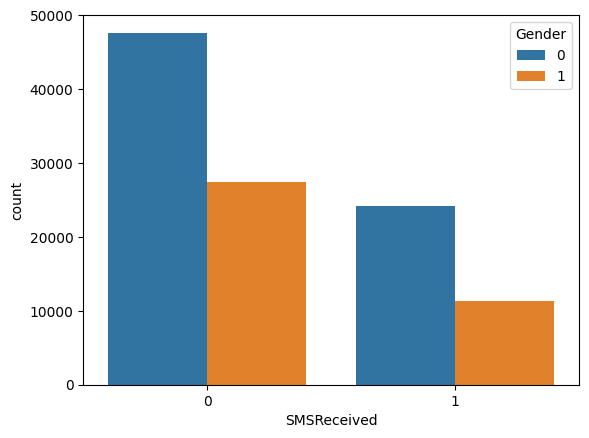

In [40]:
sns.countplot(x = df['SMSReceived'], hue= df['Gender'])

In [41]:
pd.crosstab(df['SMSReceived'],df['Gender'])

Gender,0,1
SMSReceived,,
0,47638,27407
1,24202,11280


In [42]:
47638/(47638+24202)*100

66.31124721603562

In [43]:
27407/(27407+11280)*100

70.84291880993615

### 66% Females and 70% Males are not received SMS. SMS service is not up to mark and not that much useful so we have find another way to reach patient and Increase the ratio of show

### Neighbourhood

In [44]:
df['Neighbourhood'].value_counts()

Neighbourhood
JARDIM CAMBURI                 7717
MARIA ORTIZ                    5805
RESISTÊNCIA                    4431
JARDIM DA PENHA                3877
ITARARÉ                        3514
                               ... 
ILHA DO BOI                      35
ILHA DO FRADE                    10
AEROPORTO                         8
ILHAS OCEÂNICAS DE TRINDADE       2
PARQUE INDUSTRIAL                 1
Name: count, Length: 81, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

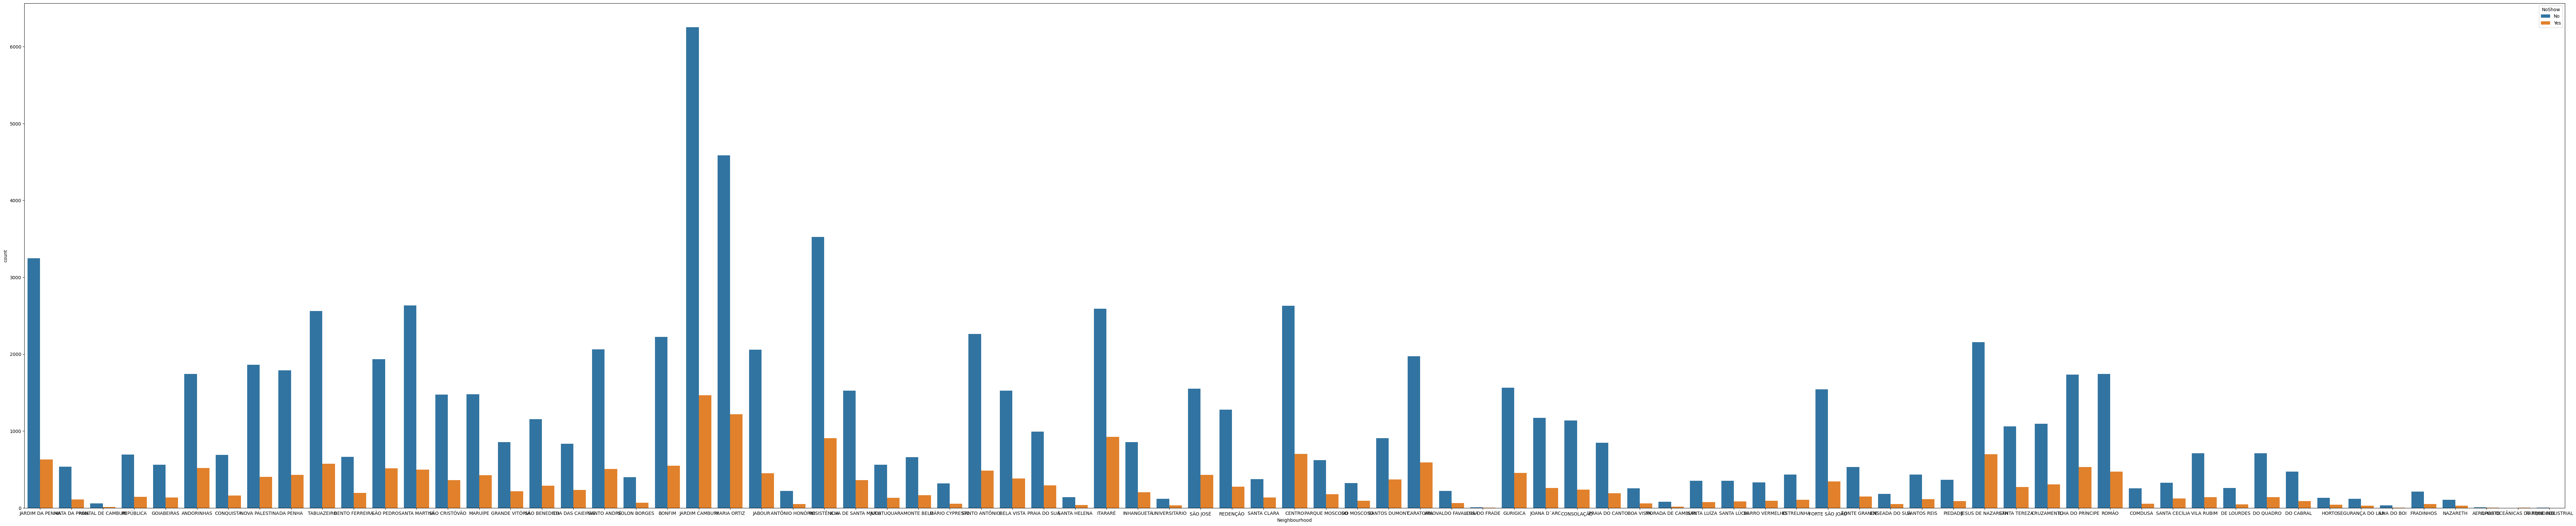

In [45]:
plt.figure(figsize=(100,20)) 
sns.countplot(x = df['Neighbourhood'], hue= df['NoShow'])
plt.savefig('Neighbourhood.png')
plt.show


##### JARDIM CAMBURI And Maria Ortiz city have lots of patient as compare to others. And also the high percetage of now attending the appointment . Conclusion is that there is high percentage of NOSHOW 

In [46]:
xdf = pd.DataFrame(df[(df['Neighbourhood'] == 'JARDIM CAMBURI') | (df['Neighbourhood'] == 'MARIA ORTIZ')])


In [47]:
pd.crosstab(xdf['Neighbourhood'],xdf['NoShow'])

NoShow,No,Yes
Neighbourhood,,
JARDIM CAMBURI,6252,1465
MARIA ORTIZ,4586,1219


### Checking whether any Appointment days are before Scheduled days

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentId   110527 non-null  int64  
 2   Gender          110527 non-null  int64  
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  float64
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMSReceived     110527 non-null  int64  
 13  NoShow          110527 non-null  object 
dtypes: float64(2), int64(8), object(4)
memory usage: 11.8+ MB


In [49]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"]) # COnverting Date from String type to Datetime format
df['ScheduledDate'] = df['ScheduledDay'].dt.date 

In [50]:
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"]) ##COnverting Date from String type to Datetime format
df['AppointmentDate'] = df['AppointmentDay'].dt.date


In [51]:
len(df[df["AppointmentDay"] < df["ScheduledDay"]])

38568

In [52]:
df['AppointmentDay'] = df['AppointmentDay'] + pd.Timedelta('1d') - pd.Timedelta('1s')
df.head()


,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow,ScheduledDate,AppointmentDate
0,2.987250e+13,5642903,0,2016-04-29 18:38:08+00:00,2016-04-29 23:59:59+00:00,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No,2016-04-29,2016-04-29
1,5.589978e+14,5642503,1,2016-04-29 16:08:27+00:00,2016-04-29 23:59:59+00:00,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No,2016-04-29,2016-04-29
2,4.262962e+12,5642549,0,2016-04-29 16:19:04+00:00,2016-04-29 23:59:59+00:00,62.0,MATA DA PRAIA,0,0,0,0,0,0,No,2016-04-29,2016-04-29
3,8.679512e+11,5642828,0,2016-04-29 17:29:31+00:00,2016-04-29 23:59:59+00:00,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No,2016-04-29,2016-04-29
4,8.841186e+12,5642494,0,2016-04-29 16:07:23+00:00,2016-04-29 23:59:59+00:00,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No,2016-04-29,2016-04-29


In [53]:
len(df[ df.AppointmentDay < df.ScheduledDay ])

5

In [54]:
df.drop( df[df.AppointmentDay <= df.ScheduledDay].index, inplace=True)
df.head()

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow,ScheduledDate,AppointmentDate
0,2.987250e+13,5642903,0,2016-04-29 18:38:08+00:00,2016-04-29 23:59:59+00:00,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No,2016-04-29,2016-04-29
1,5.589978e+14,5642503,1,2016-04-29 16:08:27+00:00,2016-04-29 23:59:59+00:00,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No,2016-04-29,2016-04-29
2,4.262962e+12,5642549,0,2016-04-29 16:19:04+00:00,2016-04-29 23:59:59+00:00,62.0,MATA DA PRAIA,0,0,0,0,0,0,No,2016-04-29,2016-04-29
3,8.679512e+11,5642828,0,2016-04-29 17:29:31+00:00,2016-04-29 23:59:59+00:00,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No,2016-04-29,2016-04-29
4,8.841186e+12,5642494,0,2016-04-29 16:07:23+00:00,2016-04-29 23:59:59+00:00,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No,2016-04-29,2016-04-29


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110522 entries, 0 to 110526
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   PatientId        110522 non-null  float64            
 1   AppointmentId    110522 non-null  int64              
 2   Gender           110522 non-null  int64              
 3   ScheduledDay     110522 non-null  datetime64[ns, UTC]
 4   AppointmentDay   110522 non-null  datetime64[ns, UTC]
 5   Age              110522 non-null  float64            
 6   Neighbourhood    110522 non-null  object             
 7   Scholarship      110522 non-null  int64              
 8   Hipertension     110522 non-null  int64              
 9   Diabetes         110522 non-null  int64              
 10  Alcoholism       110522 non-null  int64              
 11  Handcap          110522 non-null  int64              
 12  SMSReceived      110522 non-null  int64              
 13  NoSh

### Adding Week Days

In [56]:
df['AppointmentDayofWeek']=df['AppointmentDay'].dt.date
df['AppointmentDayofWeek']=pd.to_datetime(df['AppointmentDayofWeek'])
df['AppointmentDayofWeek']=df['AppointmentDayofWeek'].dt.day_name()

### Adding 'Lead Day' Column

In [57]:
df['LeadDays']=(df['AppointmentDay']-df['ScheduledDay']).dt.days.astype(int)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110522 entries, 0 to 110526
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   PatientId             110522 non-null  float64            
 1   AppointmentId         110522 non-null  int64              
 2   Gender                110522 non-null  int64              
 3   ScheduledDay          110522 non-null  datetime64[ns, UTC]
 4   AppointmentDay        110522 non-null  datetime64[ns, UTC]
 5   Age                   110522 non-null  float64            
 6   Neighbourhood         110522 non-null  object             
 7   Scholarship           110522 non-null  int64              
 8   Hipertension          110522 non-null  int64              
 9   Diabetes              110522 non-null  int64              
 10  Alcoholism            110522 non-null  int64              
 11  Handcap               110522 non-null  int64             

#### Age

In [59]:
df[df['Age']<0]

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow,ScheduledDate,AppointmentDate,AppointmentDayofWeek,LeadDays
99832,4.659432e+14,5775010,0,2016-06-06 08:58:13+00:00,2016-06-06 23:59:59+00:00,-1.0,ROMÃO,0,0,0,0,0,0,No,2016-06-06,2016-06-06,Monday,0


In [60]:
df.drop([99832],axis=0,inplace=True) #deleting -1 column

In [61]:
df[df['Age']<0]

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow,ScheduledDate,AppointmentDate,AppointmentDayofWeek,LeadDays


In [62]:
df.tail(5)

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow,ScheduledDate,AppointmentDate,AppointmentDayofWeek,LeadDays
110522,2.572134e+12,5651768,0,2016-05-03 09:15:35+00:00,2016-06-07 23:59:59+00:00,56.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-05-03,2016-06-07,Tuesday,35
110523,3.596266e+12,5650093,0,2016-05-03 07:27:33+00:00,2016-06-07 23:59:59+00:00,51.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-05-03,2016-06-07,Tuesday,35
110524,1.557663e+13,5630692,0,2016-04-27 16:03:52+00:00,2016-06-07 23:59:59+00:00,21.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-04-27,2016-06-07,Tuesday,41
110525,9.213493e+13,5630323,0,2016-04-27 15:09:23+00:00,2016-06-07 23:59:59+00:00,38.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-04-27,2016-06-07,Tuesday,41
110526,3.775115e+14,5629448,0,2016-04-27 13:30:56+00:00,2016-06-07 23:59:59+00:00,54.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-04-27,2016-06-07,Tuesday,41


### Creating Bins and buckets for Age

In [63]:
df_for_plot =df.copy()

In [64]:
Bins =[0,15,30,45,60,111]
Buckets =['0-15Yrs','15-30Yrs','30-45Yrs','45-60Yrs','60 Above']
df_for_plot['Age_Bracket']=pd.cut(df_for_plot['Age'],bins= Bins, right=False,labels=Buckets,include_lowest=True,)

In [65]:
df_for_plot.head()

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow,ScheduledDate,AppointmentDate,AppointmentDayofWeek,LeadDays,Age_Bracket
0,2.987250e+13,5642903,0,2016-04-29 18:38:08+00:00,2016-04-29 23:59:59+00:00,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No,2016-04-29,2016-04-29,Friday,0,60 Above
1,5.589978e+14,5642503,1,2016-04-29 16:08:27+00:00,2016-04-29 23:59:59+00:00,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No,2016-04-29,2016-04-29,Friday,0,45-60Yrs
2,4.262962e+12,5642549,0,2016-04-29 16:19:04+00:00,2016-04-29 23:59:59+00:00,62.0,MATA DA PRAIA,0,0,0,0,0,0,No,2016-04-29,2016-04-29,Friday,0,60 Above
3,8.679512e+11,5642828,0,2016-04-29 17:29:31+00:00,2016-04-29 23:59:59+00:00,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No,2016-04-29,2016-04-29,Friday,0,0-15Yrs
4,8.841186e+12,5642494,0,2016-04-29 16:07:23+00:00,2016-04-29 23:59:59+00:00,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No,2016-04-29,2016-04-29,Friday,0,45-60Yrs


In [66]:
df_for_plot['Age_Bracket'].isna().sum()

0

In [67]:
df_for_plot[df_for_plot['Age']<0]

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow,ScheduledDate,AppointmentDate,AppointmentDayofWeek,LeadDays,Age_Bracket


In [68]:
pd.crosstab(df_for_plot['Age_Bracket'],df_for_plot['NoShow'])[:1]

NoShow,No,Yes
Age_Bracket,,
0-15Yrs,18331,4925


In [69]:
pd.crosstab(df_for_plot['Age_Bracket'],df_for_plot['NoShow'])[1:2]

NoShow,No,Yes
Age_Bracket,,
15-30Yrs,15658,5193


<Axes: xlabel='Age_Bracket', ylabel='count'>

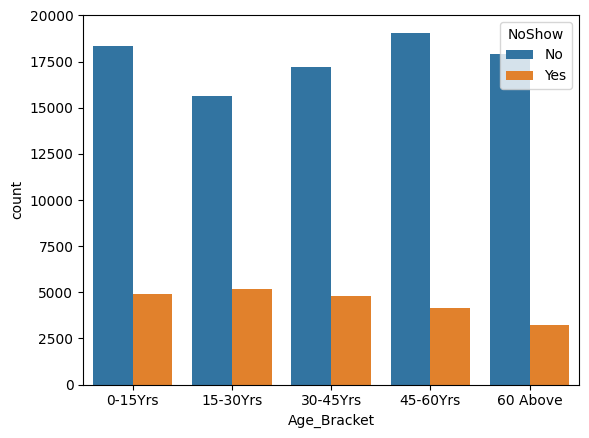

In [70]:
sns.countplot(x = df_for_plot['Age_Bracket'], hue= df_for_plot['NoShow'])

##### 15-30 Years have more number of NoShow as compare to Others

##### 45-60 Years have less number of NoShow as compare to others Means they are regularly attending their appointment

In [71]:
df_for_plot['LeadDays'].max()

179

In [72]:
Bins =[0,2,7,14,21,28,179]
Buckets =['withinn 2 Days','within Week','within 2 weeks','within 3 weeks','within 4 weeks','After 1 month']
df_for_plot['leadDay Bracket']=pd.cut(df_for_plot['LeadDays'],bins= Bins,labels=Buckets,include_lowest=True)

In [73]:
df_for_plot.tail()

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow,ScheduledDate,AppointmentDate,AppointmentDayofWeek,LeadDays,Age_Bracket,leadDay Bracket
110522,2.572134e+12,5651768,0,2016-05-03 09:15:35+00:00,2016-06-07 23:59:59+00:00,56.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-05-03,2016-06-07,Tuesday,35,45-60Yrs,After 1 month
110523,3.596266e+12,5650093,0,2016-05-03 07:27:33+00:00,2016-06-07 23:59:59+00:00,51.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-05-03,2016-06-07,Tuesday,35,45-60Yrs,After 1 month
110524,1.557663e+13,5630692,0,2016-04-27 16:03:52+00:00,2016-06-07 23:59:59+00:00,21.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-04-27,2016-06-07,Tuesday,41,15-30Yrs,After 1 month
110525,9.213493e+13,5630323,0,2016-04-27 15:09:23+00:00,2016-06-07 23:59:59+00:00,38.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-04-27,2016-06-07,Tuesday,41,30-45Yrs,After 1 month
110526,3.775115e+14,5629448,0,2016-04-27 13:30:56+00:00,2016-06-07 23:59:59+00:00,54.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-04-27,2016-06-07,Tuesday,41,45-60Yrs,After 1 month


In [74]:
df_for_plot['leadDay Bracket'].isna().mean()*100

0.0

In [75]:
df_for_plot['leadDay Bracket'].value_counts()

leadDay Bracket
withinn 2 Days    50500
within Week       20247
After 1 month     12171
within 2 weeks    12025
within 3 weeks     8874
within 4 weeks     6704
Name: count, dtype: int64

<Axes: xlabel='leadDay Bracket', ylabel='count'>

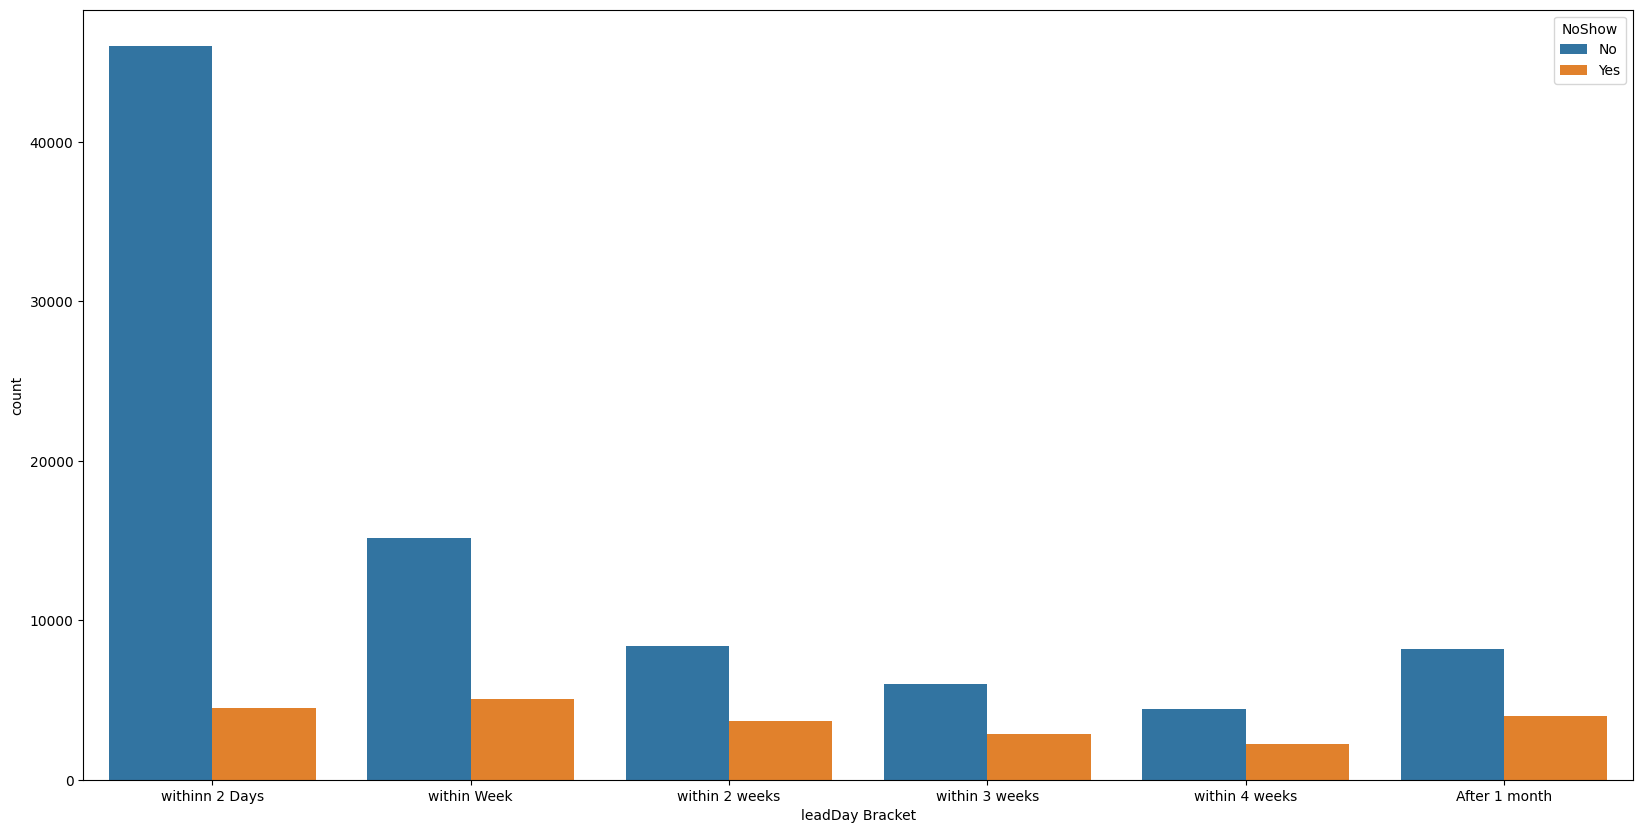

In [76]:
plt.figure(figsize=(20,10))
sns.countplot(x=df_for_plot['leadDay Bracket'],hue=df_for_plot['NoShow'])

In [77]:
pd.crosstab(df_for_plot['leadDay Bracket'],df['NoShow'])

NoShow,No,Yes
leadDay Bracket,,
withinn 2 Days,45993,4507
within Week,15190,5057
within 2 weeks,8361,3664
within 3 weeks,6013,2861
within 4 weeks,4447,2257
After 1 month,8203,3968


##### Patient whos appointment within 2 Days is more likely to attend their appointment


##### Patient who have appointment after 2 days but within a week that patient is more likely to not showing up on their appointment  

### AppointmentDayofWeek

<Axes: xlabel='AppointmentDayofWeek', ylabel='count'>

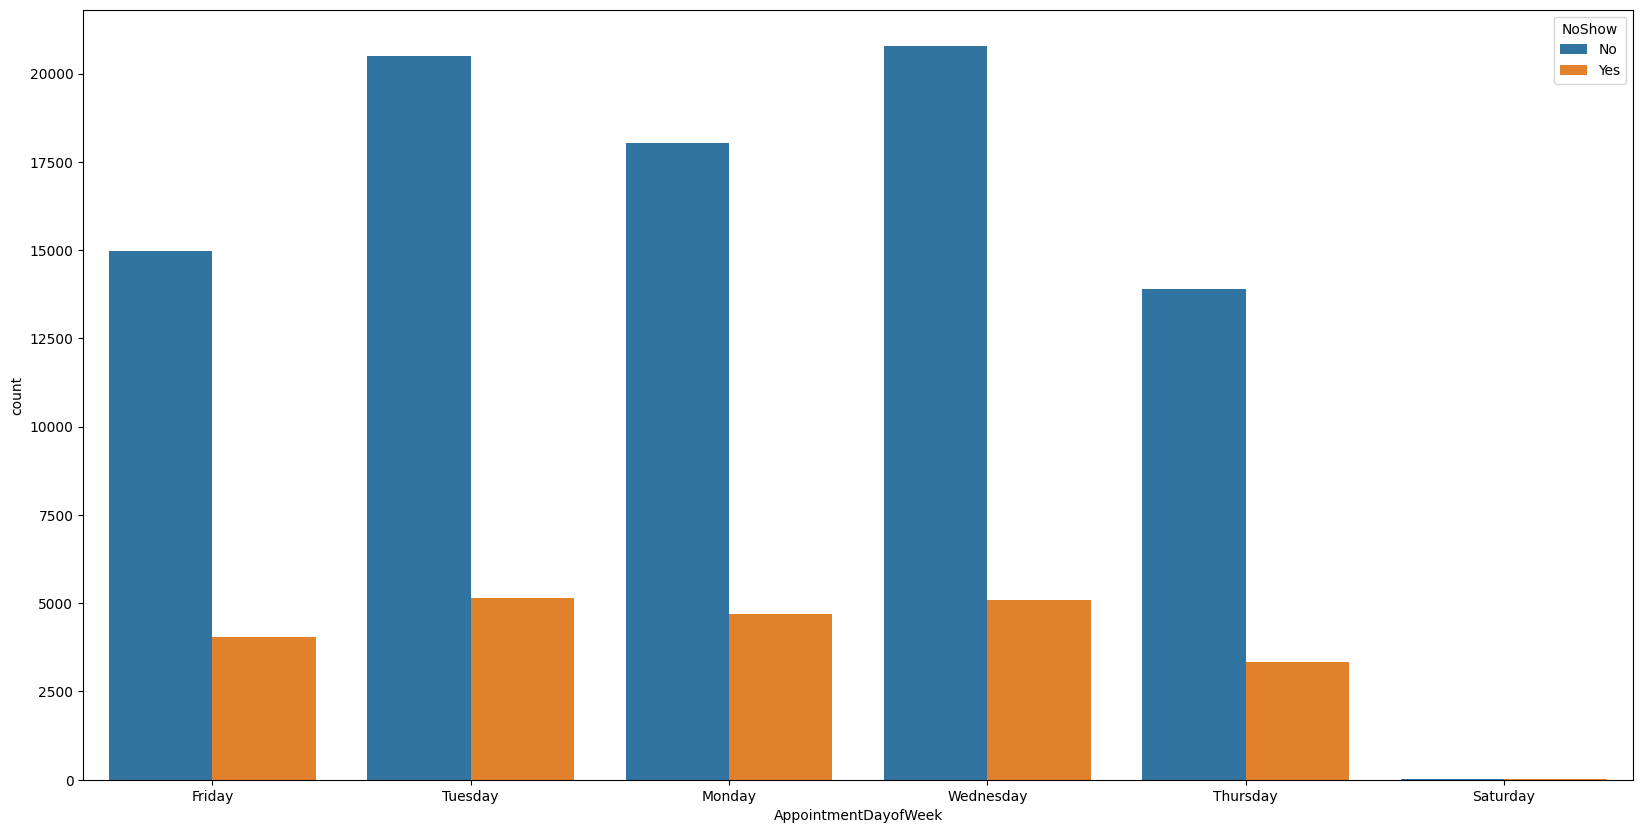

In [78]:
plt.figure(figsize=(20,10))
sns.countplot(x=df_for_plot['AppointmentDayofWeek'],hue=df_for_plot['NoShow'])

In [79]:
pd.crosstab(df_for_plot['AppointmentDayofWeek'],df['NoShow'],normalize='index')*100

NoShow,No,Yes
AppointmentDayofWeek,,
Friday,78.773858,21.226142
Monday,79.355435,20.644565
Saturday,76.923077,23.076923
Thursday,80.650586,19.349414
Tuesday,79.912630,20.087370
Wednesday,80.313926,19.686074


##### Genrally more people attend appoinments On Thursday

##### And People not showing up on Saturday

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110521 entries, 0 to 110526
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   PatientId             110521 non-null  float64            
 1   AppointmentId         110521 non-null  int64              
 2   Gender                110521 non-null  int64              
 3   ScheduledDay          110521 non-null  datetime64[ns, UTC]
 4   AppointmentDay        110521 non-null  datetime64[ns, UTC]
 5   Age                   110521 non-null  float64            
 6   Neighbourhood         110521 non-null  object             
 7   Scholarship           110521 non-null  int64              
 8   Hipertension          110521 non-null  int64              
 9   Diabetes              110521 non-null  int64              
 10  Alcoholism            110521 non-null  int64              
 11  Handcap               110521 non-null  int64             

In [81]:
df_for_sample = df_for_plot.copy()
df_for_sample

,PatientId,AppointmentId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMSReceived,NoShow,ScheduledDate,AppointmentDate,AppointmentDayofWeek,LeadDays,Age_Bracket,leadDay Bracket
0,2.987250e+13,5642903,0,2016-04-29 18:38:08+00:00,2016-04-29 23:59:59+00:00,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No,2016-04-29,2016-04-29,Friday,0,60 Above,withinn 2 Days
1,5.589978e+14,5642503,1,2016-04-29 16:08:27+00:00,2016-04-29 23:59:59+00:00,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No,2016-04-29,2016-04-29,Friday,0,45-60Yrs,withinn 2 Days
2,4.262962e+12,5642549,0,2016-04-29 16:19:04+00:00,2016-04-29 23:59:59+00:00,62.0,MATA DA PRAIA,0,0,0,0,0,0,No,2016-04-29,2016-04-29,Friday,0,60 Above,withinn 2 Days
3,8.679512e+11,5642828,0,2016-04-29 17:29:31+00:00,2016-04-29 23:59:59+00:00,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No,2016-04-29,2016-04-29,Friday,0,0-15Yrs,withinn 2 Days
4,8.841186e+12,5642494,0,2016-04-29 16:07:23+00:00,2016-04-29 23:59:59+00:00,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No,2016-04-29,2016-04-29,Friday,0,45-60Yrs,withinn 2 Days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,0,2016-05-03 09:15:35+00:00,2016-06-07 23:59:59+00:00,56.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-05-03,2016-06-07,Tuesday,35,45-60Yrs,After 1 month
110523,3.596266e+12,5650093,0,2016-05-03 07:27:33+00:00,2016-06-07 23:59:59+00:00,51.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-05-03,2016-06-07,Tuesday,35,45-60Yrs,After 1 month
110524,1.557663e+13,5630692,0,2016-04-27 16:03:52+00:00,2016-06-07 23:59:59+00:00,21.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-04-27,2016-06-07,Tuesday,41,15-30Yrs,After 1 month
110525,9.213493e+13,5630323,0,2016-04-27 15:09:23+00:00,2016-06-07 23:59:59+00:00,38.0,MARIA ORTIZ,0,0,0,0,0,1,No,2016-04-27,2016-06-07,Tuesday,41,30-45Yrs,After 1 month


In [82]:
df_for_sample['Handcap'].value_counts().to_dict()

{0: 108282, 1: 2040, 2: 183, 3: 13, 4: 3}

In [83]:
df_for_sample['Handcap'].replace({'No_movement': 0,'leprosy': 1,'blind': 2,'Low_vision': 3,'Dwarfism': 4},inplace=True)
df_for_sample['NoShow'].replace({'No':0,'Yes':1}, inplace=True)

In [84]:
df_for_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110521 entries, 0 to 110526
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   PatientId             110521 non-null  float64            
 1   AppointmentId         110521 non-null  int64              
 2   Gender                110521 non-null  int64              
 3   ScheduledDay          110521 non-null  datetime64[ns, UTC]
 4   AppointmentDay        110521 non-null  datetime64[ns, UTC]
 5   Age                   110521 non-null  float64            
 6   Neighbourhood         110521 non-null  object             
 7   Scholarship           110521 non-null  int64              
 8   Hipertension          110521 non-null  int64              
 9   Diabetes              110521 non-null  int64              
 10  Alcoholism            110521 non-null  int64              
 11  Handcap               110521 non-null  int64             

### 5.Feature selection

In [85]:
df_for_sample.columns

Index(['PatientId', 'AppointmentId', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMSReceived', 'NoShow',
       'ScheduledDate', 'AppointmentDate', 'AppointmentDayofWeek', 'LeadDays',
       'Age_Bracket', 'leadDay Bracket'],
      dtype='object')

In [86]:
x = df_for_sample.drop(['NoShow','Age_Bracket','leadDay Bracket','ScheduledDate','AppointmentDate','AppointmentDayofWeek',
                        'ScheduledDay','AppointmentDay','Neighbourhood',],axis=1)  
y = df_for_sample['NoShow']

In [87]:
x1 = df_for_sample[[ 'Gender', 'Age', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMSReceived','LeadDays','NoShow']]  

<function matplotlib.pyplot.show(close=None, block=None)>

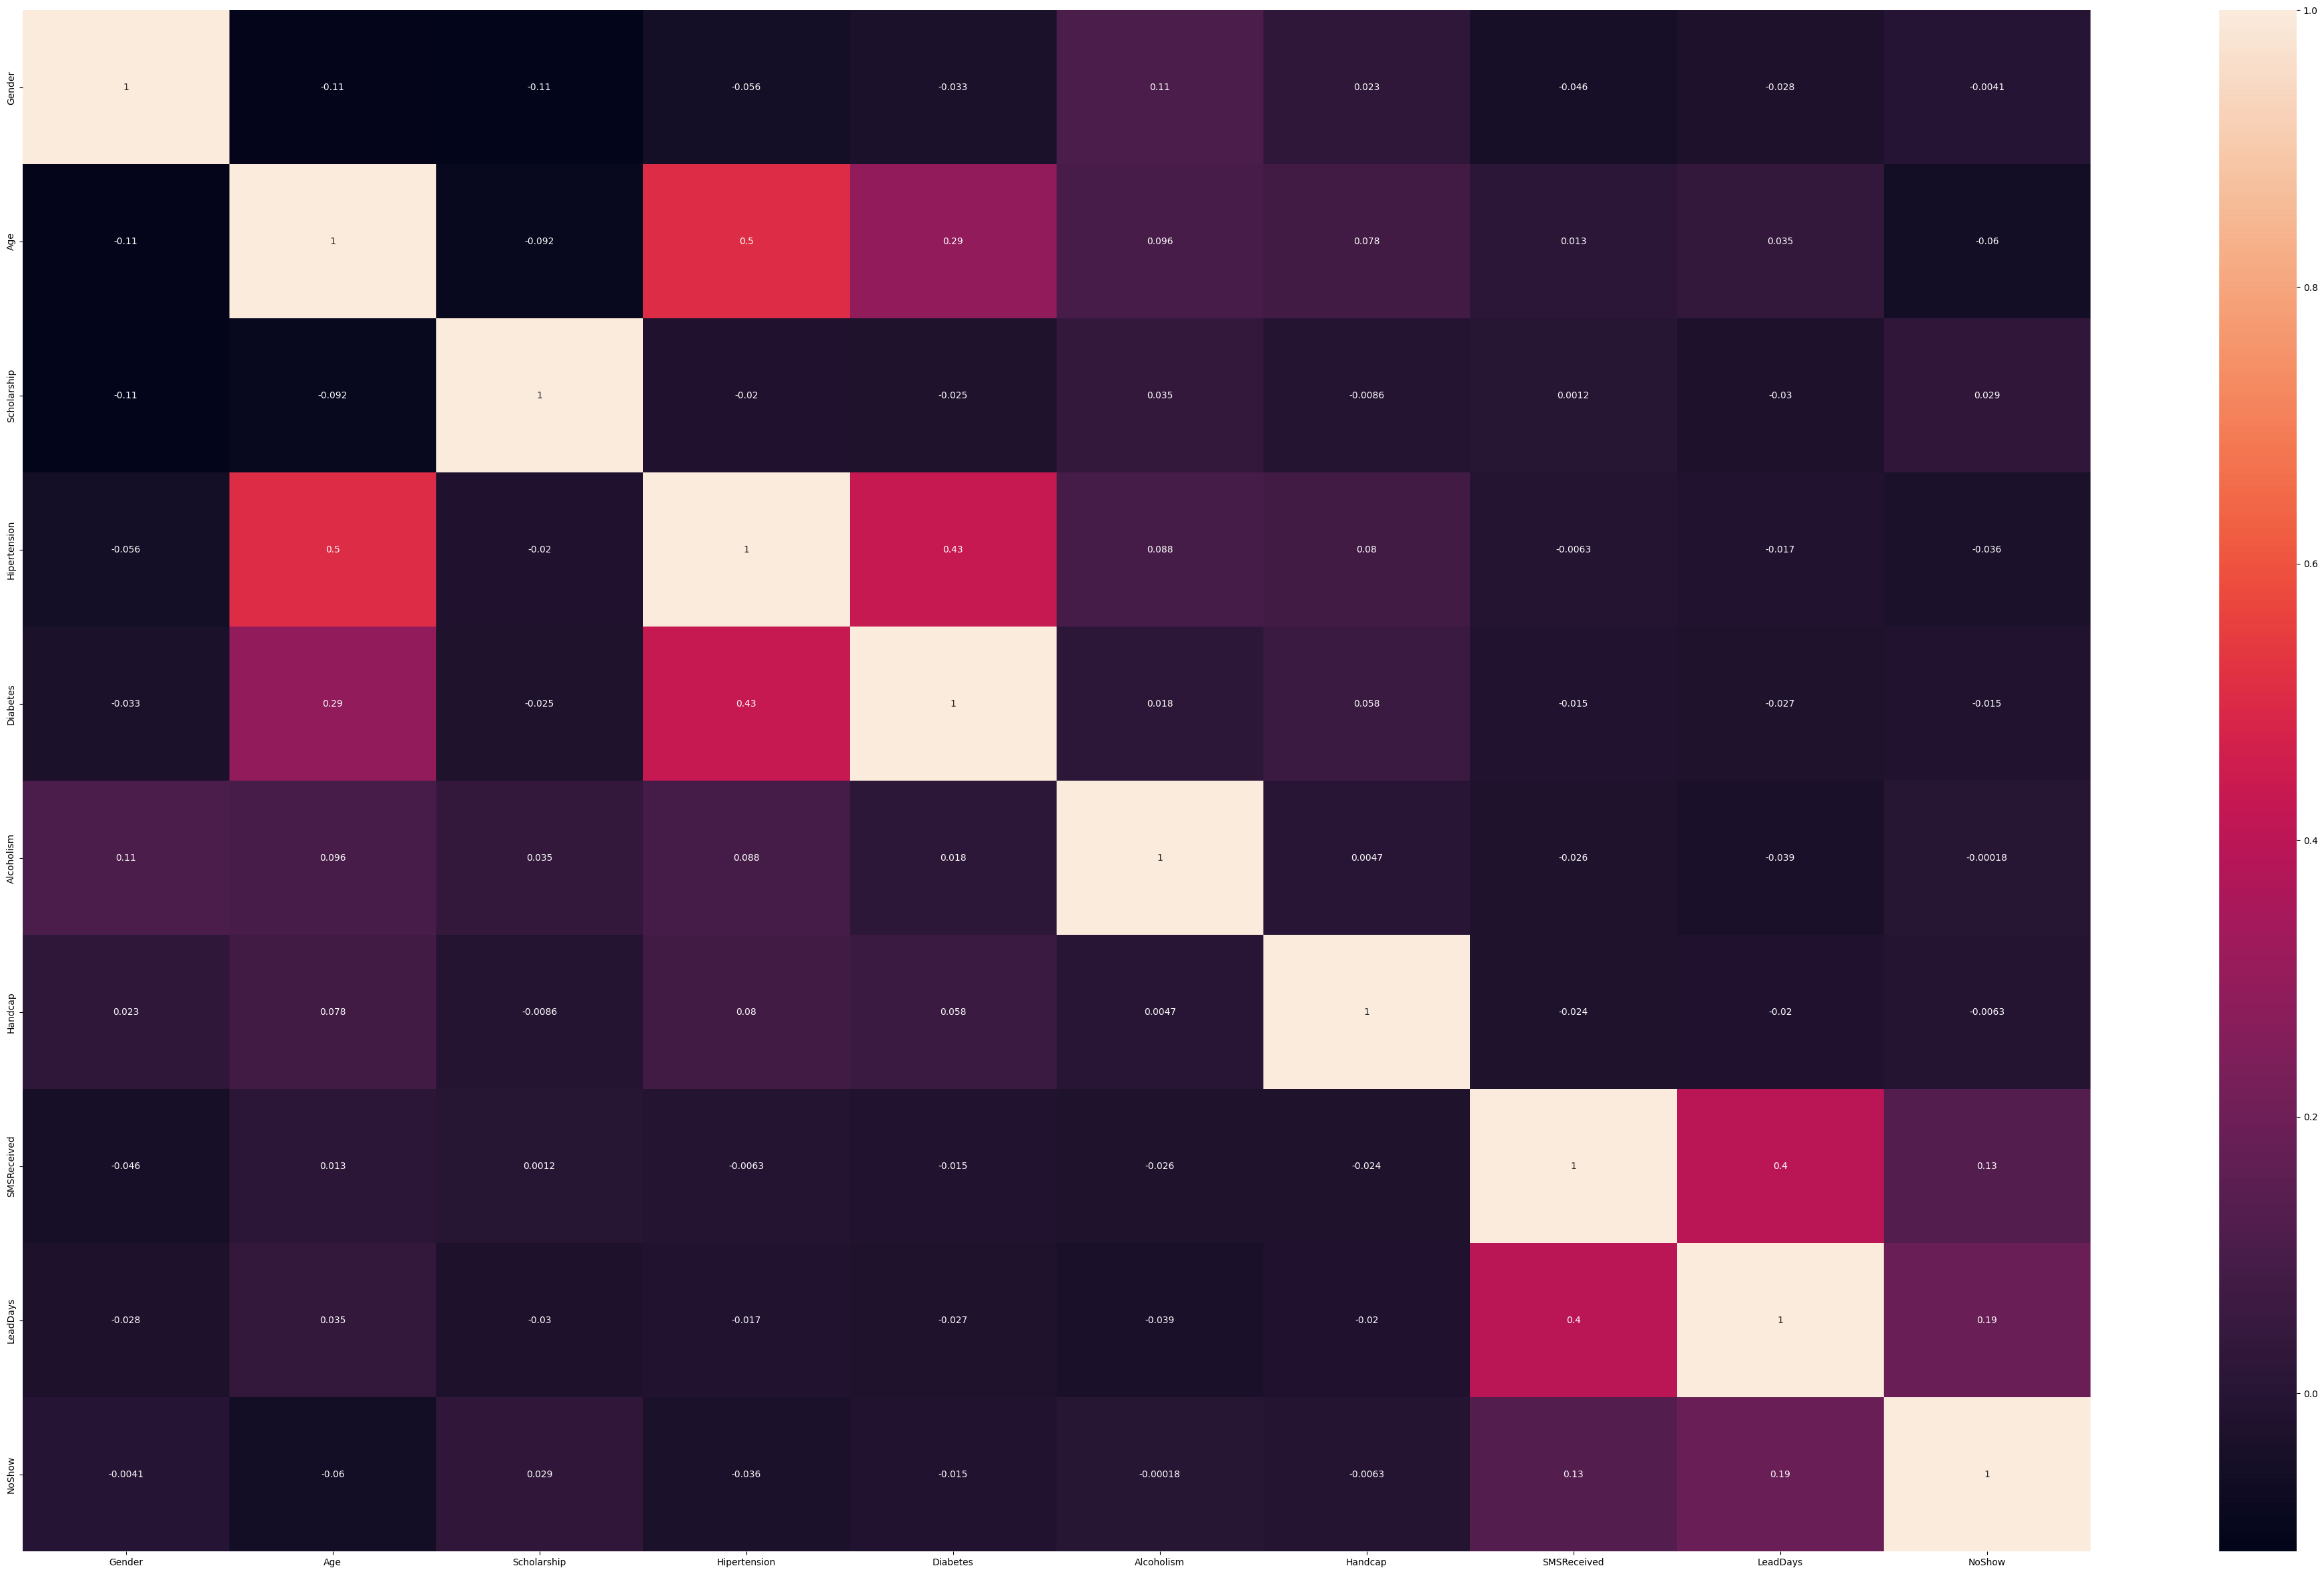

In [88]:
corr = x1.corr(method='pearson')
plt.figure(figsize=(50,30))
sns.heatmap(corr,annot=True,annot_kws={'size':10}) 
plt.show
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

In [89]:
from sklearn.feature_selection import chi2, SelectKBest, f_classif,f_regression, f_oneway

chi2_value, p_val = chi2(x,y)
chi2_df = pd.DataFrame({'Chi2-Value':np.around(chi2_value,3),'P-Val':np.around(p_val,3)}, index=x.columns)
chi2_df.sort_values('P-Val')

,Chi2-Value,P-Val
PatientId,1.072407e+14,0.000
AppointmentId,2.617792e+06,0.000
Age,5.792042e+03,0.000
Scholarship,8.477600e+01,0.000
Hipertension,1.128340e+02,0.000
Diabetes,2.356800e+01,0.000
SMSReceived,1.200839e+03,0.000
LeadDays,8.767143e+04,0.000
Handcap,5.129000e+00,0.024
Gender,1.226000e+00,0.268


In [90]:
x = df_for_sample[[ 'Gender', 'Age', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMSReceived','LeadDays']]  
y = df_for_sample['NoShow']

<Axes: >

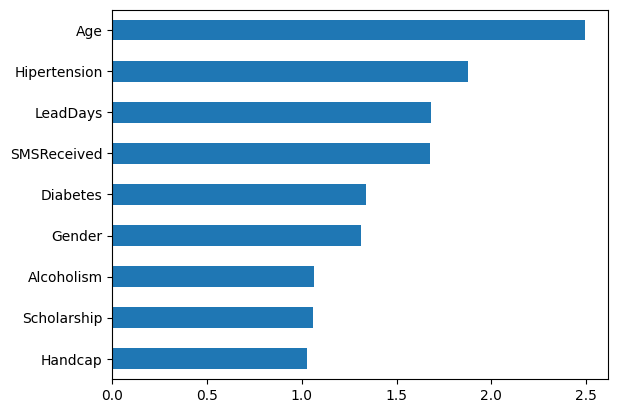

In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_list = []
for i in range(x.shape[1]):
    vif = variance_inflation_factor(x.values, i)
    vif_list.append(vif)
    
s5 = pd.Series(vif_list, index=x.columns)
s5.sort_values().plot(kind='barh')

In [92]:
from sklearn.feature_selection import chi2, SelectKBest, f_classif,f_regression, f_oneway

chi2_value, p_val = chi2(x,y)
chi2_df = pd.DataFrame({'Chi2-Value':chi2_value,'P-Val':np.around(p_val,3)}, index=x.columns)
chi2_df.sort_values('P-Val')

,Chi2-Value,P-Val
Age,5792.042379,0.000
Scholarship,84.776016,0.000
Hipertension,112.834183,0.000
Diabetes,23.567551,0.000
SMSReceived,1200.839311,0.000
LeadDays,87671.435463,0.000
Handcap,5.129381,0.024
Gender,1.226415,0.268
Alcoholism,0.003508,0.953


In [93]:
chi2_df[chi2_df['P-Val'] < 0.05].index

Index(['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Handcap',
       'SMSReceived', 'LeadDays'],
      dtype='object')

### Train-Test splitting

In [94]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=12, stratify=y)

In [95]:
df_for_sample['NoShow'].value_counts()

NoShow
0    88207
1    22314
Name: count, dtype: int64

### Balancing imbalance data by Oversampling

#### 1.RandomOversampling

In [96]:
from imblearn.over_sampling import ADASYN, RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek

In [97]:
rndm_os = RandomOverSampler(sampling_strategy=0.85)
x_train_os, y_train_os = rndm_os.fit_resample(x_train,y_train)

print('Before OverSamplingy :',y_train.value_counts())

print('After OverSampling :',y_train_os.value_counts())

Before OverSamplingy : NoShow
0    70565
1    17851
Name: count, dtype: int64
After OverSampling : NoShow
0    70565
1    59980
Name: count, dtype: int64


In [98]:
smote = SMOTE(sampling_strategy=0.9)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)
print(y_train.value_counts())
print('\n',y_train_resampled.value_counts())

NoShow
0    70565
1    17851
Name: count, dtype: int64

 NoShow
0    70565
1    63508
Name: count, dtype: int64


In [99]:
adasyn = ADASYN(sampling_strategy=0.90)
x_train_ads, y_train_ads = adasyn.fit_resample(x_train,y_train)
print(y_train.value_counts())
print(y_train_ads.value_counts())

NoShow
0    70565
1    17851
Name: count, dtype: int64
NoShow
0    70565
1    62819
Name: count, dtype: int64


## 5. Model Training

In [100]:
log_clf = LogisticRegression()
log_clf.fit(x_train, y_train)

LogisticRegression()

### Evaluation Metric

In [101]:
def evaluation(string, model, ind_var, act):
    print(string.center(50, '*'))
    pred = model.predict(ind_var)
    
    acc_score = accuracy_score(act, pred)
    print('Accuracy Score :', acc_score)
    print('**'*20)
    
    cnf_matrix = confusion_matrix(act, pred)
    print('Confusion Matrix: \n', cnf_matrix)
    print('**'*20)
    
    clf_report = classification_report(act, pred)
    print('Classification Report : \n', clf_report)
    print('**'*20)
    
    mat_coef = matthews_corrcoef(act, pred)
    print('Matthews Correlation Coeficient:', mat_coef)
    
    return pred
    
y_pred = evaluation('Test Data Evaluation',log_clf, x_test, y_test)
print()
y_pred = evaluation('Train Data Evaluation',log_clf, x_train, y_train)

***************Test Data Evaluation***************
Accuracy Score : 0.7951594661841213
****************************************
Confusion Matrix: 
 [[17513   129]
 [ 4399    64]]
****************************************
Classification Report : 
               precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.33      0.01      0.03      4463

    accuracy                           0.80     22105
   macro avg       0.57      0.50      0.46     22105
weighted avg       0.70      0.80      0.71     22105

****************************************
Matthews Correlation Coeficient: 0.03032505038256667

**************Train Data Evaluation***************
Accuracy Score : 0.7947204125950055
****************************************
Confusion Matrix: 
 [[69988   577]
 [17573   278]]
****************************************
Classification Report : 
               precision    recall  f1-score   support

           0       0.80      0.

### Sampling by Random Oversampling

In [102]:
log_clf = LogisticRegression()
log_clf.fit(x_train_os, y_train_os)
y_pred = evaluation('Test Data Evaluation',log_clf, x_test, y_test)    
y_pred_train = evaluation('Train Data Evaluation',log_clf, x_train_os, y_train_os) 

***************Test Data Evaluation***************
Accuracy Score : 0.7023750282741461
****************************************
Confusion Matrix: 
 [[13544  4098]
 [ 2481  1982]]
****************************************
Classification Report : 
               precision    recall  f1-score   support

           0       0.85      0.77      0.80     17642
           1       0.33      0.44      0.38      4463

    accuracy                           0.70     22105
   macro avg       0.59      0.61      0.59     22105
weighted avg       0.74      0.70      0.72     22105

****************************************
Matthews Correlation Coeficient: 0.19040642135187044
**************Train Data Evaluation***************
Accuracy Score : 0.6176567467156919
****************************************
Confusion Matrix: 
 [[54025 16540]
 [33373 26607]]
****************************************
Classification Report : 
               precision    recall  f1-score   support

           0       0.62      0.7

### Oversampling by SMOTE

In [103]:
log_clf = LogisticRegression()
log_clf.fit(x_train_resampled, y_train_resampled)
y_pred = evaluation('Test Data Evaluation',log_clf, x_test, y_test)    
y_pred_train = evaluation('Train Data Evaluation',log_clf, x_train_resampled, y_train_resampled)

***************Test Data Evaluation***************
Accuracy Score : 0.6955892332051572
****************************************
Confusion Matrix: 
 [[13321  4321]
 [ 2408  2055]]
****************************************
Classification Report : 
               precision    recall  f1-score   support

           0       0.85      0.76      0.80     17642
           1       0.32      0.46      0.38      4463

    accuracy                           0.70     22105
   macro avg       0.58      0.61      0.59     22105
weighted avg       0.74      0.70      0.71     22105

****************************************
Matthews Correlation Coeficient: 0.19096851425579803
**************Train Data Evaluation***************
Accuracy Score : 0.6335876723874307
****************************************
Confusion Matrix: 
 [[53400 17165]
 [31961 31547]]
****************************************
Classification Report : 
               precision    recall  f1-score   support

           0       0.63      0.7

### By ADAsyn


In [104]:
log_clf = LogisticRegression()
log_clf.fit(x_train_ads, y_train_ads)
y_pred = evaluation('Test Data Evaluation',log_clf, x_test, y_test)    
y_pred_train = evaluation('Train Data Evaluation',log_clf, x_train_ads, y_train_ads)

***************Test Data Evaluation***************
Accuracy Score : 0.694684460529292
****************************************
Confusion Matrix: 
 [[13338  4304]
 [ 2445  2018]]
****************************************
Classification Report : 
               precision    recall  f1-score   support

           0       0.85      0.76      0.80     17642
           1       0.32      0.45      0.37      4463

    accuracy                           0.69     22105
   macro avg       0.58      0.60      0.59     22105
weighted avg       0.74      0.69      0.71     22105

****************************************
Matthews Correlation Coeficient: 0.18494554311135272
**************Train Data Evaluation***************
Accuracy Score : 0.6230882264739399
****************************************
Confusion Matrix: 
 [[53596 16969]
 [33305 29514]]
****************************************
Classification Report : 
               precision    recall  f1-score   support

           0       0.62      0.76

In [ ]:
# ROS = copy

# SMOTE = create between points

# ADASYN = create more where needed

### Random Forest

In [1]:
from sklearn.ensemble import RandomForestClassifier


In [105]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=60,random_state=11, n_jobs=-1, oob_score=True)
rf_clf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=60, n_jobs=-1, oob_score=True,
                       random_state=11)

In [106]:
def evaluation(string, model, ind_var, act):
    print(string.center(50, '*'))
    
    pred = model.predict(ind_var)
    cnf_matrix = confusion_matrix(act, pred)
    print('Confusion Matrix :\n', cnf_matrix)
    
    clf_report = classification_report(act,pred)
    print('Classification Report :\n', clf_report)
    
evaluation('Train Data Evaluation', rf_clf, x_train, y_train)
print('**'*20)
evaluation('Test Data Evaluation', rf_clf, x_test, y_test)

**************Train Data Evaluation***************
Confusion Matrix :
 [[68384  2181]
 [ 9400  8451]]
Classification Report :
               precision    recall  f1-score   support

           0       0.88      0.97      0.92     70565
           1       0.79      0.47      0.59     17851

    accuracy                           0.87     88416
   macro avg       0.84      0.72      0.76     88416
weighted avg       0.86      0.87      0.86     88416

****************************************
***************Test Data Evaluation***************
Confusion Matrix :
 [[16018  1624]
 [ 3568   895]]
Classification Report :
               precision    recall  f1-score   support

           0       0.82      0.91      0.86     17642
           1       0.36      0.20      0.26      4463

    accuracy                           0.77     22105
   macro avg       0.59      0.55      0.56     22105
weighted avg       0.72      0.77      0.74     22105



In [107]:
ran_clf = RandomForestClassifier()        #randomoversampling
ran_clf.fit(x_train_os, y_train_os)
y_pred = evaluation('Test Data Evaluation',ran_clf, x_test, y_test)    
y_pred_train = evaluation('Train Data Evaluation',ran_clf, x_train_os, y_train_os) 

***************Test Data Evaluation***************
Confusion Matrix :
 [[13069  4573]
 [ 2403  2060]]
Classification Report :
               precision    recall  f1-score   support

           0       0.84      0.74      0.79     17642
           1       0.31      0.46      0.37      4463

    accuracy                           0.68     22105
   macro avg       0.58      0.60      0.58     22105
weighted avg       0.74      0.68      0.70     22105

**************Train Data Evaluation***************
Confusion Matrix :
 [[57217 13348]
 [ 9747 50233]]
Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.81      0.83     70565
           1       0.79      0.84      0.81     59980

    accuracy                           0.82    130545
   macro avg       0.82      0.82      0.82    130545
weighted avg       0.82      0.82      0.82    130545



In [108]:
rand_clf = RandomForestClassifier()        #randomoversampling
rand_clf.fit(x_train_resampled, y_train_resampled)
y_pred = evaluation('Test Data Evaluation',rand_clf, x_test, y_test)    
y_pred_train = evaluation('Train Data Evaluation',rand_clf, x_train_resampled, y_train_resampled) 

***************Test Data Evaluation***************
Confusion Matrix :
 [[13178  4464]
 [ 2477  1986]]
Classification Report :
               precision    recall  f1-score   support

           0       0.84      0.75      0.79     17642
           1       0.31      0.44      0.36      4463

    accuracy                           0.69     22105
   macro avg       0.57      0.60      0.58     22105
weighted avg       0.73      0.69      0.71     22105

**************Train Data Evaluation***************
Confusion Matrix :
 [[57863 12702]
 [10449 53059]]
Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.82      0.83     70565
           1       0.81      0.84      0.82     63508

    accuracy                           0.83    134073
   macro avg       0.83      0.83      0.83    134073
weighted avg       0.83      0.83      0.83    134073



In [109]:
randm_clf = LogisticRegression()
randm_clf.fit(x_train_ads, y_train_ads)
y_pred = evaluation('Test Data Evaluation',randm_clf, x_test, y_test)    
y_pred_train = evaluation('Train Data Evaluation',randm_clf, x_train_ads, y_train_ads)

***************Test Data Evaluation***************
Confusion Matrix :
 [[13338  4304]
 [ 2445  2018]]
Classification Report :
               precision    recall  f1-score   support

           0       0.85      0.76      0.80     17642
           1       0.32      0.45      0.37      4463

    accuracy                           0.69     22105
   macro avg       0.58      0.60      0.59     22105
weighted avg       0.74      0.69      0.71     22105

**************Train Data Evaluation***************
Confusion Matrix :
 [[53596 16969]
 [33305 29514]]
Classification Report :
               precision    recall  f1-score   support

           0       0.62      0.76      0.68     70565
           1       0.63      0.47      0.54     62819

    accuracy                           0.62    133384
   macro avg       0.63      0.61      0.61    133384
weighted avg       0.63      0.62      0.61    133384



### Hyperparameter tuning

In [110]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [111]:
log_clf = LogisticRegression()

param_grid = {'penalty': ['l1', 'l2'],  # Regularization type
    'C': uniform(0.1, 10)}      # Inverse of regularization strength
gscv_knn_clf = RandomizedSearchCV(estimator=log_clf,param_grid, scoring='accuracy')
gscv_knn_clf.fit(x_train,y_train)
gscv_knn_clf.best_estimator_

SyntaxError: positional argument follows keyword argument (2509130089.py, line 5)

In [112]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

# Define hyperparameter grid
param_grid = {
    'penalty': ['l1', 'l2'],  # Regularization type
    'C': uniform(0.1, 10)      # Inverse of regularization strength
}

# Define RandomizedSearchCV
randomized_search = RandomizedSearchCV(estimator=log_clf, param_distributions=param_grid,
                                       n_iter=100, scoring='accuracy', cv=5, random_state=42)

# Fit RandomizedSearchCV to training data
randomized_search.fit(x_train, y_train)

# Best parameters found
print("Best Parameters:", randomized_search.best_params_)

# Evaluate on test data
accuracy = randomized_search.score(x_test, y_test)
print("Accuracy:", accuracy)


Best Parameters: {'C': 3.667533266935893, 'penalty': 'l2'}
Accuracy: 0.7950689889165348


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression


# Define hyperparameter grid
param_grid = {
    'penalty': ['l1', 'l2'],  # Regularization type
    'C': [0.1, 1, 10]           # Inverse of regularization strength
}

# Create GridSearchCV
grid_search = GridSearchCV(estimator=log_clf, param_grid=param_grid,
                           scoring='accuracy', cv=5)

# Fit GridSearchCV to training data
grid_search.fit(x_train, y_train)

# Best parameters found
print("Best Parameters:", grid_search.best_params_)

# Evaluate on test data
accuracy = grid_search.score(x_test, y_test)
print("Accuracy:", accuracy)


In [113]:
y_pred = evaluation('Test Data Evaluation',grid_search, x_test, y_test)    
y_pred_train = evaluation('Train Data Evaluation',grid_search, x_train, y_train)

NameError: name 'grid_search' is not defined

In [114]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

param_grid = {'penalty': ['l1', 'l2'],  # Regularization type
    'C': uniform(0.1, 10)}

# Define RandomizedSearchCV
randomized_search = RandomizedSearchCV(estimator=log_clf, param_distributions=param_grid,
                                       n_iter=100, scoring='accuracy', cv=5, random_state=42)

randomized_search.fit(x_train, y_train)
print("Best Parameters:", randomized_search.best_params_)

accuracy = randomized_search.score(x_test, y_test)
print("Accuracy:", accuracy)

Best Parameters: {'C': 3.667533266935893, 'penalty': 'l2'}
Accuracy: 0.7950689889165348


In [115]:
knn_model = KNeighborsClassifier()

param_grid = {'n_neighbors':np.arange(3, 20),'weights':['uniform', 'distance'], 'p':[1,2], 
              'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute']}

gscv_knn_clf = GridSearchCV(knn_model, param_grid, cv=3, scoring='recall')
gscv_knn_clf.fit(x_train,y_train)
gscv_knn_clf.best_estimator_

NameError: name 'KNeighborsClassifier' is not defined

In [116]:
from lazypredict.Supervised import LazyClassifier
clf = LazyClassifier(verbose = 0, ignore_warnings = True,
                    custom_metric= None)
model, predictors = clf.fit(x_train, x_test, y_train, y_test)
print(model)

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [08:25<00:00, 53.43s/it]

[LightGBM] [Info] Number of positive: 17851, number of negative: 70565
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 241
[LightGBM] [Info] Number of data points in the train set: 88416, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.201898 -> initscore=-1.374475
[LightGBM] [Info] Start training from score -1.374475



100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [08:25<00:00, 17.44s/it]

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.65               0.62     0.62      0.69   
RandomForestClassifier             0.77               0.55     0.55      0.74   
BaggingClassifier                  0.76               0.55     0.55      0.74   
PassiveAggressiveClassifier        0.40               0.55     0.55      0.42   
ExtraTreeClassifier                0.77               0.55     0.55      0.74   
ExtraTreesClassifier               0.77               0.55     0.55      0.74   
DecisionTreeClassifier             0.77               0.55     0.55      0.74   
KNeighborsClassifier               0.76               0.54     0.54      0.73   
GaussianNB                         0.77               0.53     0.53      0.73   
QuadraticDiscriminantAnalysis      0.78               0.53     0.53      0.73   
Perceptron                  

### 2.Decision Tree Classifier

In [2]:
from sklearn.tree import DecisionTreeClassifier


In [117]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=20, criterion='gini')
dt_clf.fit(x_train, y_train)

DecisionTreeClassifier(random_state=20)

In [118]:
def evaluation(string, model, ind_var, act):
    print(string.center(55, '*'))
    pred = model.predict(ind_var)
    
    cnf_mat = confusion_matrix(act, pred)
    print('Confusion Matrix : \n', cnf_mat)
    
    clf_report = classification_report(act, pred)
    print('\nClassification Report : \n', clf_report)
    
    return cnf_mat

evaluation('Test Data Evaluation', dt_clf, x_train, y_train)
print()
evaluation('Train Data Evaluation', dt_clf, x_test, y_test)

******************Test Data Evaluation*****************
Confusion Matrix : 
 [[69468  1097]
 [10473  7378]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.87      0.98      0.92     70565
           1       0.87      0.41      0.56     17851

    accuracy                           0.87     88416
   macro avg       0.87      0.70      0.74     88416
weighted avg       0.87      0.87      0.85     88416


*****************Train Data Evaluation*****************
Confusion Matrix : 
 [[16127  1515]
 [ 3660   803]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.82      0.91      0.86     17642
           1       0.35      0.18      0.24      4463

    accuracy                           0.77     22105
   macro avg       0.58      0.55      0.55     22105
weighted avg       0.72      0.77      0.74     22105



array([[16127,  1515],
       [ 3660,   803]], dtype=int64)

In [119]:
#decision tree got overfitted so applying randomized search cv
from sklearn.model_selection import RandomizedSearchCV
params={ 'max_depth':[None, 5], 'min_samples_leaf':[5,10], "criterion":["gini","entropy"]}
dt_clf_hyp = DecisionTreeClassifier(random_state=2)
clf_grid = RandomizedSearchCV(dt_clf_hyp, params, cv=5, n_jobs=-1, verbose=1)
clf_grid.fit(x, y)
print(clf_grid.best_params_)
print(clf_grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
{'min_samples_leaf': 5, 'max_depth': 5, 'criterion': 'gini'}
0.7981379107855828


In [120]:
rncv_model = clf_grid.best_params_
rncv_model = DecisionTreeClassifier(min_samples_leaf = 5, max_depth= 5, criterion ='gini')
rncv_model.fit(x_train, y_train)
evaluation('Test Data Evaluation', rncv_model, x_train, y_train)
print()
evaluation('Train Data Evaluation', rncv_model, x_test, y_test)

******************Test Data Evaluation*****************
Confusion Matrix : 
 [[70565     0]
 [17851     0]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     70565
           1       0.00      0.00      0.00     17851

    accuracy                           0.80     88416
   macro avg       0.40      0.50      0.44     88416
weighted avg       0.64      0.80      0.71     88416


*****************Train Data Evaluation*****************
Confusion Matrix : 
 [[17642     0]
 [ 4463     0]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     17642
           1       0.00      0.00      0.00      4463

    accuracy                           0.80     22105
   macro avg       0.40      0.50      0.44     22105
weighted avg       0.64      0.80      0.71     22105



array([[17642,     0],
       [ 4463,     0]], dtype=int64)

### 3. RandomForestClassifier

In [121]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=100,random_state=2, n_jobs=-1, oob_score=True)
rf_clf.fit(x_train, y_train)

RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=2)

In [122]:
evaluation('Test Data Evaluation', rf_clf, x_train, y_train)
print()
evaluation('Train Data Evaluation', rf_clf, x_test, y_test)

******************Test Data Evaluation*****************
Confusion Matrix : 
 [[68569  1996]
 [ 9575  8276]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.88      0.97      0.92     70565
           1       0.81      0.46      0.59     17851

    accuracy                           0.87     88416
   macro avg       0.84      0.72      0.76     88416
weighted avg       0.86      0.87      0.85     88416


*****************Train Data Evaluation*****************
Confusion Matrix : 
 [[16101  1541]
 [ 3592   871]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.82      0.91      0.86     17642
           1       0.36      0.20      0.25      4463

    accuracy                           0.77     22105
   macro avg       0.59      0.55      0.56     22105
weighted avg       0.73      0.77      0.74     22105



array([[16101,  1541],
       [ 3592,   871]], dtype=int64)

In [123]:
#model get overfitted applying hyperparameter tuning
params = {'n_estimators':[10,20], 'max_depth':[None, 5], 'min_samples_split':[2,3]}
rf_clf_hyp = RandomForestClassifier(random_state=0)
rncv_clf = RandomizedSearchCV(rf_clf_hyp, params, cv=5, n_jobs=-1, verbose=1)
rncv_clf.fit(x,y)
print(rncv_clf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
{'n_estimators': 20, 'min_samples_split': 2, 'max_depth': 5}


In [124]:
params={'n_estimators':[10,20], 'max_depth':[None, 5], 'min_samples_split':[2,3]}
rf_clf_hyp = RandomForestClassifier(random_state=0)
clf_grid = RandomizedSearchCV(rf_clf_hyp, params, cv=5, n_jobs=-1, verbose=1)
clf_grid.fit(x, y)
print(clf_grid.best_params_)
print(clf_grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
{'n_estimators': 20, 'min_samples_split': 2, 'max_depth': 5}
0.7981017182412469


# 6.4 AdaBoostClassifier

In [125]:
from sklearn.ensemble import AdaBoostClassifier
ab_clf = AdaBoostClassifier(n_estimators=100,random_state=2)
ab_clf.fit(x_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=2)

In [126]:
evaluation('Test Data Evaluation', ab_clf, x_test, y_test)
print()
evaluation('Train Data Evaluation', ab_clf, x_train, y_train)

******************Test Data Evaluation*****************
Confusion Matrix : 
 [[17619    23]
 [ 4430    33]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     17642
           1       0.59      0.01      0.01      4463

    accuracy                           0.80     22105
   macro avg       0.69      0.50      0.45     22105
weighted avg       0.76      0.80      0.71     22105


*****************Train Data Evaluation*****************
Confusion Matrix : 
 [[70437   128]
 [17726   125]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     70565
           1       0.49      0.01      0.01     17851

    accuracy                           0.80     88416
   macro avg       0.65      0.50      0.45     88416
weighted avg       0.74      0.80      0.71     88416



array([[70437,   128],
       [17726,   125]], dtype=int64)

In [127]:
params={'n_estimators':[100]}
ab_clf_hyp = AdaBoostClassifier(random_state=0)
clf_grid = RandomizedSearchCV(ab_clf_hyp, params, cv=5, verbose=1)
clf_grid.fit(x, y)
print(clf_grid.best_params_)
print(clf_grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
{'n_estimators': 100}
0.7972059593181393


In [128]:
ab_clf = AdaBoostClassifier(n_estimators=100,random_state=19)
ab_clf.fit(x_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=19)

In [129]:

evaluation('Test Data Evaluation', ab_clf, x_test, y_test)
print()
evaluation('Train Data Evaluation', ab_clf, x_train, y_train)

******************Test Data Evaluation*****************
Confusion Matrix : 
 [[17619    23]
 [ 4430    33]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     17642
           1       0.59      0.01      0.01      4463

    accuracy                           0.80     22105
   macro avg       0.69      0.50      0.45     22105
weighted avg       0.76      0.80      0.71     22105


*****************Train Data Evaluation*****************
Confusion Matrix : 
 [[70437   128]
 [17726   125]]

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     70565
           1       0.49      0.01      0.01     17851

    accuracy                           0.80     88416
   macro avg       0.65      0.50      0.45     88416
weighted avg       0.74      0.80      0.71     88416



array([[70437,   128],
       [17726,   125]], dtype=int64)

# 6.5 LGBMClassifier

In [130]:
lgb_clf = LGBMClassifier(boosting_type="gbdt",num_leaves=31,max_depth=10,n_estimators=100,random_state=2,n_jobs=-1)
lgb_clf.fit(x_train, y_train)

NameError: name 'LGBMClassifier' is not defined

In [131]:
def evaluation(string, model, ind_var, act):
    print(string.center(55, '*'))
    pred = model.predict(ind_var)
    
    cnf_mat = confusion_matrix(act, pred)
    print('Confusion Matrix : \n', cnf_mat)
    
    mat_cor = matthews_corrcoef(act,pred)
    print('Matthews Correlation Coef : ', mat_cor)
    
    clf_report = classification_report(act, pred)
    print('\nClassification Report : \n', clf_report)
    
    return cnf_mat

evaluation('Test Data Evaluation', lgb_clf, x_test, y_test)
print()
cnf_matrix = evaluation('Train Data Evaluation', lgb_clf, x_train, y_train)

NameError: name 'lgb_clf' is not defined

In [132]:
params={'n_estimators':[100],"max-depth":[-1],"n_jobs":[4],"silent":[True],"metric":[None]}
lgb_clf_hyp = LGBMClassifier(random_state=19)
clf_grid = RandomizedSearchCV(lgb_clf_hyp, params, cv=5, verbose=1,scoring="roc_auc")
clf_grid.fit(x, y)
print(clf_grid.best_params_)
print(clf_grid.best_score_)

NameError: name 'LGBMClassifier' is not defined

In [133]:
lgb_clf = LGBMClassifier(boosting_type="gbdt",num_leaves=31,max_depth=-1,n_estimators=100,random_state=2,n_jobs=4)
lgb_clf.fit(x_train, y_train)

NameError: name 'LGBMClassifier' is not defined

In [134]:
def evaluation(string, model, ind_var, act):
    print(string.center(55, '*'))
    pred = model.predict(ind_var)
    
    cnf_mat = confusion_matrix(act, pred)
    print('Confusion Matrix : \n', cnf_mat)
    
    mat_cor = matthews_corrcoef(act,pred)
    print('Matthews Correlation Coef : ', mat_cor)
    
    clf_report = classification_report(act, pred)
    print('\nClassification Report : \n', clf_report)
    
    return cnf_mat

evaluation('Test Data Evaluation', lgb_clf, x_test, y_test)
print()
cnf_matrix = evaluation('Train Data Evaluation', lgb_clf, x_train, y_train)

NameError: name 'lgb_clf' is not defined

# 6.6 XGBoostClassifier

In [135]:
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(random_state=2)
xgb_clf.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=2, ...)

In [136]:

evaluation('Test Data Evaluation', xgb_clf, x_test, y_test)
print()
evaluation('Train Data Evaluation', xgb_clf, x_train, y_train)

******************Test Data Evaluation*****************
Confusion Matrix : 
 [[17469   173]
 [ 4304   159]]
Matthews Correlation Coef :  0.08521525778355801

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.48      0.04      0.07      4463

    accuracy                           0.80     22105
   macro avg       0.64      0.51      0.48     22105
weighted avg       0.74      0.80      0.72     22105


*****************Train Data Evaluation*****************
Confusion Matrix : 
 [[70204   361]
 [16791  1060]]
Matthews Correlation Coef :  0.17322005755814518

Classification Report : 
               precision    recall  f1-score   support

           0       0.81      0.99      0.89     70565
           1       0.75      0.06      0.11     17851

    accuracy                           0.81     88416
   macro avg       0.78      0.53      0.50     88416
weighted avg       0.79      0.8

array([[70204,   361],
       [16791,  1060]], dtype=int64)

In [137]:
params={"booster":["gbtree"],"silent":[0],"nthread":[10],"max_depth":[5],"max_leaf_nodes":[10],"min_child_weight":[6], "gamma":[0], "subsample":[0.8], "colsample_bytree":[0.8],"objective":['binary:logistic'], "scale_pos_weight":[1],"seed":[27],"n_jobs":[4],"iid":[False]}
xgb_clf_hyp = XGBClassifier(random_state=19)
clf_grid = RandomizedSearchCV(xgb_clf_hyp, params, cv=5, verbose=1,scoring="roc_auc")
clf_grid.fit(x, y)
print(clf_grid.best_params_)
print(clf_grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
{'subsample': 0.8, 'silent': 0, 'seed': 27, 'scale_pos_weight': 1, 'objective': 'binary:logistic', 'nthread': 10, 'n_jobs': 4, 'min_child_weight': 6, 'max_leaf_nodes': 10, 'max_depth': 5, 'iid': False, 'gamma': 0, 'colsample_bytree': 0.8, 'booster': 'gbtree'}
0.7181646371688343


In [138]:
xgb_clf=XGBClassifier(subsample=0.8,silent=0,seed=27,scale_pos_weight=1,objective='binary:logistic',nthread=10,n_jobs=4,min_child_weight=6,max_leaf_nodes=10,max_depth=5,iid=False,colsample_bytree=0.8,booster='gbtree')
xgb_clf.fit(x_train,y_train)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, iid=False, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaf_nodes=10,
              max_leaves=None, min_child_weight=6, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=4, ...)

In [139]:
evaluation('Test Data Evaluation', xgb_clf, x_test, y_test)
print()
cnf_matrix = evaluation('Train Data Evaluation', xgb_clf, x_train, y_train)

******************Test Data Evaluation*****************
Confusion Matrix : 
 [[17495   147]
 [ 4338   125]]
Matthews Correlation Coef :  0.07164335130765237

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.46      0.03      0.05      4463

    accuracy                           0.80     22105
   macro avg       0.63      0.51      0.47     22105
weighted avg       0.73      0.80      0.72     22105


*****************Train Data Evaluation*****************
Confusion Matrix : 
 [[70177   388]
 [17123   728]]
Matthews Correlation Coef :  0.12687002729147845

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      0.99      0.89     70565
           1       0.65      0.04      0.08     17851

    accuracy                           0.80     88416
   macro avg       0.73      0.52      0.48     88416
weighted avg       0.77      0.8

In [140]:
#dumping the model into pickle file
import pickle
with open(r'D:\DATA SCIENCE\PROJECT\ML\noshow prediction\model.pkl','wb') as f:
    pickle.dump(xgb_clf, f)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\DATA SCIENCE\\PROJECT\\ML\\noshow prediction\\model.pkl'

In [141]:
#loading the saved model
with open(r"model.pkl",'rb') as f:
    loaded_data = pickle.load(f)
loaded_data

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, iid=False, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaf_nodes=10,
              max_leaves=None, min_child_weight=6, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=4, ...)